In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import pickle
import joblib
from sklearn.pipeline import Pipeline 

In [3]:
Audi = pd.read_csv('audi.csv')
BMW = pd.read_csv('bmw.csv')
VW = pd.read_csv('vw.csv')
Mercedes = pd.read_csv('merc.csv')

In [4]:
Audi.head()
BMW.head()
VW.head()
Mercedes.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,SLK,2005,5200,Automatic,63000,Petrol,325,32.1,1.8
1,S Class,2017,34948,Automatic,27000,Hybrid,20,61.4,2.1
2,SL CLASS,2016,49948,Automatic,6200,Petrol,555,28.0,5.5
3,G Class,2016,61948,Automatic,16000,Petrol,325,30.4,4.0
4,G Class,2016,73948,Automatic,4000,Petrol,325,30.1,4.0


In [5]:
Data = pd.concat([VW, Audi,BMW,Mercedes], ignore_index=True)

In [6]:
Data

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0
3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0
4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5
...,...,...,...,...,...,...,...,...,...
49720,C Class,2020,35999,Automatic,500,Diesel,145,55.4,2.0
49721,B Class,2020,24699,Automatic,2500,Diesel,145,55.4,2.0
49722,GLC Class,2019,30999,Automatic,11612,Diesel,145,41.5,2.1
49723,CLS Class,2019,37990,Automatic,2426,Diesel,145,45.6,2.0


In [7]:
Audi_Models = Audi['model'].unique()
BMW_Models = BMW['model'].unique()
VW_Models = VW['model'].unique()
Merc_Models = Mercedes['model'].unique()


In [8]:
import numpy as np


conditions = [
    Data['model'].isin(Audi['model'].unique()),
    Data['model'].isin(BMW['model'].unique()),
    Data['model'].isin(VW['model'].unique()),
    Data['model'].isin(Mercedes['model'].unique())
]

choices = ['Audi', 'BMW', 'Volkswagen', 'Mercedes']


Data['company'] = np.select(conditions, choices, default='Other')

In [9]:
#Data.drop('Company',axis=1,inplace=True)

In [10]:
Data.describe()

,year,price,mileage,tax,mpg,engineSize
count,49725.000000,49725.000000,49725.000000,49725.000000,49725.000000,49725.000000
mean,2017.194852,21490.188255,23379.721830,124.246154,54.056947,1.918665
std,2.191633,11094.741909,22642.502451,64.821295,19.250044,0.588176
min,1970.000000,650.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,13995.000000,5891.000000,125.000000,44.800000,1.500000
50%,2017.000000,19498.000000,16908.000000,145.000000,53.300000,2.000000
75%,2019.000000,26090.000000,33981.000000,145.000000,61.400000,2.000000
max,2020.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


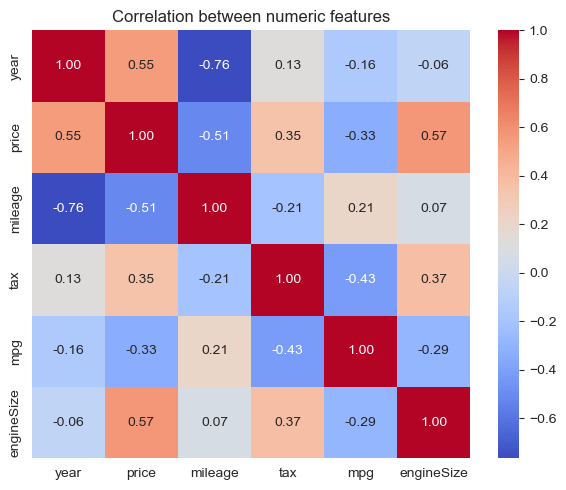

In [11]:
sns.set_style("whitegrid")

# Correlation heatmap — only numeric columns
numeric_cols = Data.select_dtypes(include=np.number).columns
plt.figure(figsize=(6, 5))
sns.heatmap(Data[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()


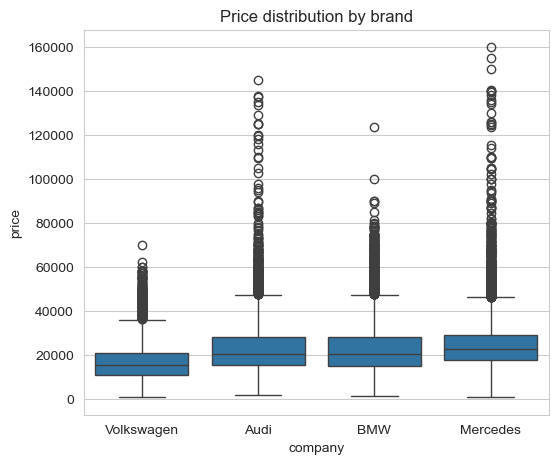

In [12]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=Data, x="company", y="price")
plt.title("Price distribution by brand")
plt.show()


<Axes: xlabel='mpg', ylabel='price'>

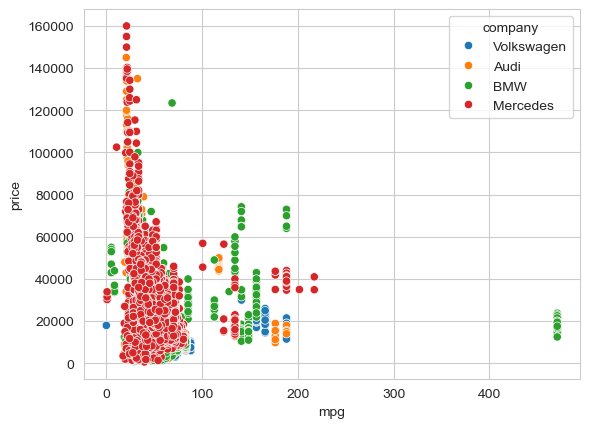

In [13]:
sns.scatterplot(data=Data,x='mpg',y='price',hue='company')

<Axes: xlabel='mpg', ylabel='price'>

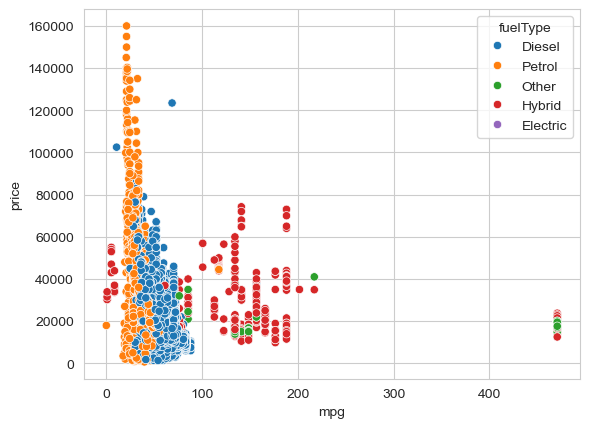

In [14]:
sns.scatterplot(data=Data,x='mpg',y='price',hue='fuelType')

In [15]:
Data[Data['fuelType']=='Electric']

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,company
34200,i3,2017,18999,Automatic,20321,Electric,135,470.8,0.0,BMW
34225,i3,2016,18999,Automatic,9990,Electric,0,470.8,0.0,BMW
34660,i3,2015,17400,Automatic,29465,Electric,0,470.8,1.0,BMW


In [16]:
Current_Year = 2026
Data['Car_Age'] = (Current_Year - Data['year'])
Data["mileage_per_year"] = Data["mileage"] / Data["Car_Age"].replace(0, 1)


In [17]:
Data.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,company,Car_Age,mileage_per_year
49720,C Class,2020,35999,Automatic,500,Diesel,145,55.4,2.0,Mercedes,6,83.333333
49721,B Class,2020,24699,Automatic,2500,Diesel,145,55.4,2.0,Mercedes,6,416.666667
49722,GLC Class,2019,30999,Automatic,11612,Diesel,145,41.5,2.1,Mercedes,7,1658.857143
49723,CLS Class,2019,37990,Automatic,2426,Diesel,145,45.6,2.0,Mercedes,7,346.571429
49724,S Class,2019,54999,Automatic,2075,Diesel,145,52.3,2.9,Mercedes,7,296.428571


In [18]:
#IQR for Handling Outlier
Q1 = Data['price'].quantile(0.25)
Q3 = Data['price'].quantile(0.75)

IQR = Q3-Q1
Lower = Q1 - 1.5*IQR
Upper = Q3 + 1.5*IQR

before = len(Data)
Data = Data[(Data["price"] >= Lower) & (Data["price"] <= Upper)].copy()
print(f"Removed {before - len(Data)} price outliers out of {before} rows")
Data[["price", "Car_Age", "mileage_per_year"]].describe()

Removed 2083 price outliers out of 49725 rows


,price,Car_Age,mileage_per_year
count,47642.000000,47642.000000,47642.000000
mean,19988.702133,8.881533,2419.877431
std,8116.478015,2.199432,1935.609381
min,650.000000,6.000000,0.040000
25%,13824.750000,7.000000,858.857143
50%,18998.000000,9.000000,2056.866071
75%,25041.750000,10.000000,3495.310606
max,44212.000000,56.000000,24049.400000


In [19]:
Categorical_Columns = ['transmission','fuelType','company']
Categorical_Columns

Numeric_Columns = [col for col in Data.columns
                   if col not in Categorical_Columns + ['price', 'model']]

print("Categorical:", Categorical_Columns)
print("Numeric:", Numeric_Columns)

X = Data[Categorical_Columns + Numeric_Columns]   
y = Data['price']

Categorical: ['transmission', 'fuelType', 'company']
Numeric: ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'Car_Age', 'mileage_per_year']


In [20]:
#Data.drop('Company',axis=1,inplace=True)

In [21]:
Data

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,company,Car_Age,mileage_per_year
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,Volkswagen,7,1986.285714
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,Volkswagen,7,651.714286
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,Volkswagen,7,1059.142857
3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,Volkswagen,7,689.285714
4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,Volkswagen,7,928.571429
...,...,...,...,...,...,...,...,...,...,...,...,...
49719,C Class,2020,30999,Automatic,1000,Diesel,145,64.2,2.0,Mercedes,6,166.666667
49720,C Class,2020,35999,Automatic,500,Diesel,145,55.4,2.0,Mercedes,6,83.333333
49721,B Class,2020,24699,Automatic,2500,Diesel,145,55.4,2.0,Mercedes,6,416.666667
49722,GLC Class,2019,30999,Automatic,11612,Diesel,145,41.5,2.1,Mercedes,7,1658.857143


In [22]:
Encoded_Data = pd.get_dummies(Data, columns=Categorical_Columns, drop_first=True)
Model = Encoded_Data.drop(columns=['model','year','mileage'])
Model.head() 

,price,tax,mpg,engineSize,Car_Age,mileage_per_year,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,company_BMW,company_Mercedes,company_Volkswagen
0,25000,145,49.6,2.0,7,1986.285714,False,False,False,False,False,False,False,False,False,True
1,26883,145,49.6,2.0,7,651.714286,False,False,False,False,False,False,False,False,False,True
2,20000,145,50.4,2.0,7,1059.142857,True,False,False,False,False,False,False,False,False,True
3,33492,145,32.5,2.0,7,689.285714,False,False,False,False,False,False,True,False,False,True
4,22900,150,39.8,1.5,7,928.571429,False,False,True,False,False,False,True,False,False,True


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

X = Model.drop(columns=['price'])
y = Model['price']

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [33]:
def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    print(f"{name}:  R2={r2:.3f}   MAE=£{mae:,.0f}   RMSE=£{rmse:,.0f}")
    return {"model": name, "r2": r2, "mae": mae, "rmse": rmse}

Lr = LinearRegression()
Lr.fit(X_train,y_train)
Lr_results = evaluate('Linear Regression',Lr,X_test,y_test)

Rf = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
Rf.fit(X_train,y_train)
Rf_results = evaluate('Random Forest Regressor',Rf,X_test,y_test)
Rf_small = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
Rf_small.fit(X_train, y_train)

Rf_small_results = evaluate('Random Forest (compact)', Rf_small, X_test, y_test)



Linear Regression:  R2=0.782   MAE=£2,770   RMSE=£3,787
Random Forest Regressor:  R2=0.923   MAE=£1,542   RMSE=£2,246
Random Forest (compact):  R2=0.926   MAE=£1,532   RMSE=£2,205
23.8 MB


In [26]:
Results = pd.DataFrame([Lr_results, Rf_results]).set_index("model")
Results

,r2,mae,rmse
model,,,
Linear Regression,0.782233,2769.537944,3787.397367
Random Forest Regressor,0.923410,1541.698633,2246.114397


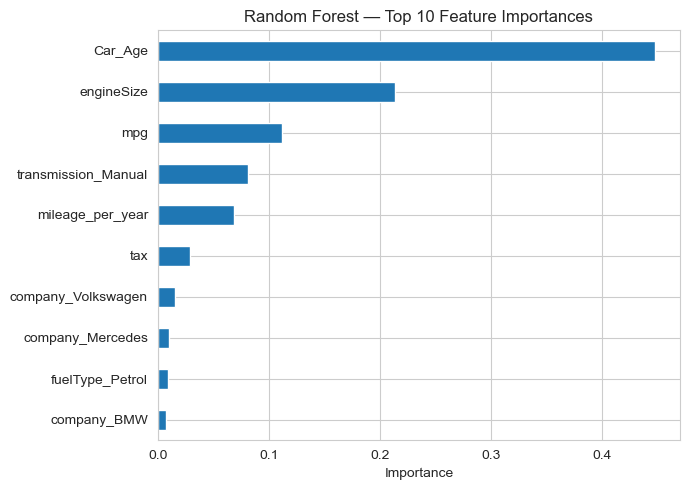

In [27]:
importances = pd.Series(Rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(7, 5))
importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Random Forest — Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [28]:
def predict_price(model, brand, transmission, fuel_type, car_age, mileage_per_year, engine_size, tax=145, mpg=50):
    row = pd.DataFrame([{
        "tax": tax, "mpg": mpg, "engineSize": engine_size,
        "Car_age": car_age, "mileage_per_year": mileage_per_year,
    }])
    for col in X.columns:
        if col not in row.columns:
            row[col] = 0
    # flip on the relevant one-hot columns if they exist
    for flag, val in [(f"transmission_{transmission}", 1), (f"fuelType_{fuel_type}", 1), (f"company_{brand}", 1)]:
        if flag in row.columns:
            row[flag] = val
    row = row[X.columns]
    return model.predict(row)[0]

example_price = predict_price(Rf, brand="VW", transmission="Manual", fuel_type="Petrol",
                               car_age=4, mileage_per_year=9000, engine_size=1.6)
print(f"Predicted price: £{example_price:,.0f}")


Predicted price: £18,156


In [29]:
# Save Model
pickle.dump(Rf,open('model.pkl','wb'))
print('Model trained and saved Successfully')
joblib.dump(Rf, 'car_price_model.pkl', compress=3)

Model trained and saved Successfully


['car_price_model.pkl']

In [41]:
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42))
])

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)
print(preds[:5])
joblib.dump(Rf_small, 'car_price_model.pkl', compress=3)

import os
print(f"{os.path.getsize('car_price_model.pkl') / (1024*1024):.1f} MB")

[31900.28       14387.28       18187.81        6865.96666667
 17657.16333333]
23.8 MB


In [42]:
pipeline = joblib.load("car_price_model.pkl")
pipeline.predict(X_test)

array([31826.95260967, 14750.875     , 18475.14813662, ...,
       14988.15527331, 29750.5438769 , 28266.54516185], shape=(11911,))

In [43]:
import os
print(f"{os.path.getsize('car_price_model.pkl') / (1024*1024):.1f} MB")

23.8 MB
